In [67]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torchvision import transforms as T
import numpy as np
import matplotlib.pyplot as plt

In [68]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(NeuralNetwork, self).__init__()
        self.lin1 = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        out = self.lin1(x)
        return out

In [69]:
x = torch.linspace(-10000, 10000, 2000, dtype=torch.float32)
y = torch.mul(x, 2)

In [70]:
x.shape # ! (total_no_of_training_examples)
y.shape # ! (total_no_of_training_examples)


x = x.view(-1, 1) # ! (total_no_of_training_examples, 1)
y = y.view(-1, 1) # ! (total_no_of_training_examples, 1)
print(x.shape)
print(y.shape)

torch.Size([2000, 1])
torch.Size([2000, 1])


In [71]:
model = NeuralNetwork(1, 10, 1)
optimizer = Adam(model.parameters(), lr=0.1)
criterion = nn.MSELoss()
epochs = 500
for epoch in range(epochs):
    pred = model(x)
    loss = criterion(pred, y)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch: {epoch+1}/{epochs}, Loss: {loss:.4f}")
    

Epoch: 10/500, Loss: 58842416.0000
Epoch: 20/500, Loss: 7465450.0000
Epoch: 30/500, Loss: 201288.0781
Epoch: 40/500, Loss: 2004244.6250
Epoch: 50/500, Loss: 797927.0625
Epoch: 60/500, Loss: 7189.3433
Epoch: 70/500, Loss: 77843.5781
Epoch: 80/500, Loss: 37307.7344
Epoch: 90/500, Loss: 0.1846
Epoch: 100/500, Loss: 4904.4717
Epoch: 110/500, Loss: 968.4035
Epoch: 120/500, Loss: 161.9686
Epoch: 130/500, Loss: 249.8551
Epoch: 140/500, Loss: 0.3892
Epoch: 150/500, Loss: 29.8331
Epoch: 160/500, Loss: 2.7085
Epoch: 170/500, Loss: 2.4520
Epoch: 180/500, Loss: 0.8038
Epoch: 190/500, Loss: 0.1639
Epoch: 200/500, Loss: 0.1403
Epoch: 210/500, Loss: 0.0101
Epoch: 220/500, Loss: 0.0201
Epoch: 230/500, Loss: 0.0007
Epoch: 240/500, Loss: 0.0027
Epoch: 250/500, Loss: 0.0001
Epoch: 260/500, Loss: 0.0004
Epoch: 270/500, Loss: 0.0000
Epoch: 280/500, Loss: 0.0000
Epoch: 290/500, Loss: 0.0000
Epoch: 300/500, Loss: 0.0000
Epoch: 310/500, Loss: 0.0000
Epoch: 320/500, Loss: 0.0000
Epoch: 330/500, Loss: 0.0000
Ep

In [83]:
import matplotlib.pyplot as plt

with torch.no_grad():
    x_test = torch.linspace(20000, 30000, 10, dtype=torch.float32).view(-1, 1)
    y_test = torch.mul(x_test.view(-1), 2)
    y_pred = model(x_test)
    # print(y_pred.shape)
    # print(y_test.shape)
    loss = torch.sub(y_test, y_pred.view(-1)).sum(0)
    print(f"Testing Loss: {loss}")
    

Testing Loss: 0.0


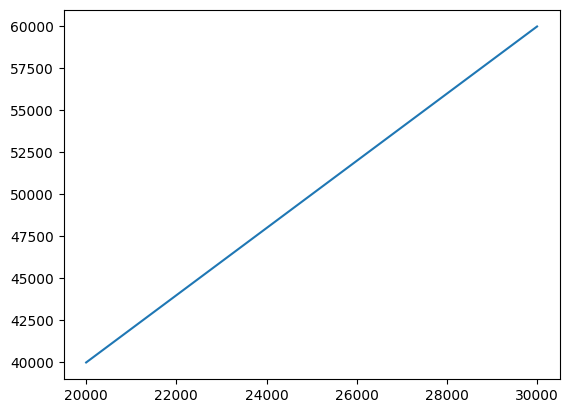

In [75]:
plt.plot(x_test.view(-1), y_pred.view(-1))
# plt.plot(x_test.view(-1), y_test.view(-1))
plt.show()

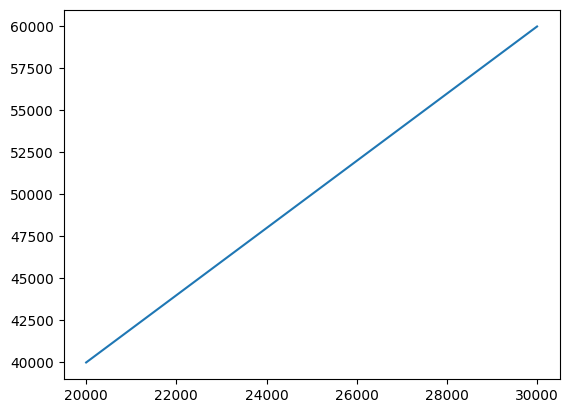

In [76]:
# plt.plot(x_test.view(-1), y_pred.view(-1))
plt.plot(x_test.view(-1), y_test.view(-1))
plt.show()